# 自然锁死：多维数据上，正确公式因首次拟合落入局部极小而被永久排除

**目的**：上一个实验（`test_fit_failure_lockin.ipynb`）用受控注入强制拟合失败，留下的疑问是——这种事在真实运行中会发生吗？本实验的回答是肯定的：**不做任何注入、不改变 `mcmc.py` 的任何行为**，只换一组多维输入的数据，真公式的首次拟合就从默认初值（全 1.0）出发自然收敛到错误的局部极小，随后被同一套记录机制永久冻结。

**三个环节**（`machine-scientist/mcmc.py`；本次出场的是 B 与 C）：

| 环节 | 位置 | 行为 |
|---|---|---|
| A | `mcmc.py:685-689` | `curve_fit` 抛异常时，未经拟合的初值照样写入 `fit_par`（上一实验已验证，本次不需要它出场） |
| B | `mcmc.py:655-656` | `fit_par` 命中即复用，不区分拟合好坏，错误的结果再无重拟合的机会 |
| C | `mcmc.py:789-793, 797-801` | canonical 首次出现即以当时能量登记为"代表"，且**永不更新**；等价形式一律 `return -1` 被拒 |

**物理设定**：真定律 $y = a/(x_1 - b)$（a=3, b=4，极点在数据区间之外），输入是多维的（$x_1$ 与干扰变量 $x_2$）。这类含极点（或频率）的非线性参数对初值极其敏感：默认初值 $b_0=1$ 把极点放在数据区间正中央，最小二乘从此滑入错误的极小。

**实验设计**：

1. **基线**：同一棵真公式树，默认初值 vs 合理初值——命运的岔口只在出发位置；
2. **环节 B、C 的自然验证**：无任何注入，连异常都不需要；
3. **MCMC 对照**：两条链从真公式出发，唯一差别是出发时的参数初值；
4. **解除冻结**：清除错误记录后，公式恢复其真实能量。

## 0. 数据与模型设定

真公式 $y = a/(x_1 - b)$，a=3、b=4（极点 $x_1=4$ 在数据区间 (0.2, 3.5) 之外）；30 个数据点，噪声 N(0, 0.05)；$x_2$ 是不出现在真定律中的干扰变量。固定随机种子保证可复现。每个候选公式的能量取 $E = \mathrm{BIC}/2 + E_P$（BIC 近似下的负对数后验加先验项），MCMC 以 $\propto e^{-E}$ 的权重在公式空间中游走。

（备注：真公式写成 `(_a_ / (x1 + -(_b_)))` 的一元负号形式，因为 `from_string` 会把中缀 `x1 - _b_` 解析成二元 `-` 节点，与 `OPS['-']==1` 矛盾——这是解析器的另一个独立问题，此处只绕道，不展开。）

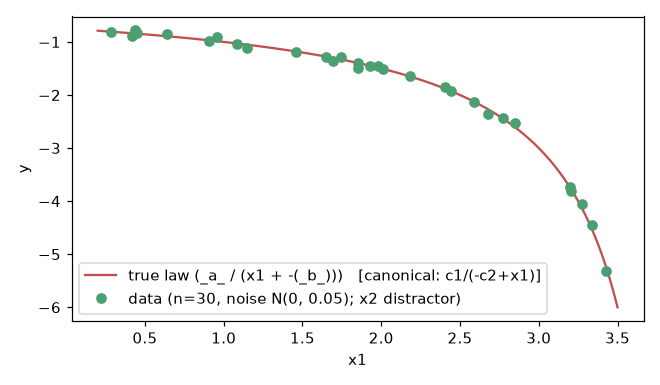

In [1]:
import sys, json, time, io
sys.path.append('..')
import numpy as np
import pandas as pd
from random import seed
from copy import deepcopy
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import mcmc
from mcmc import Tree

seed(7); np.random.seed(7)
n = 30
x = pd.DataFrame({'x1': np.random.uniform(0.2, 3.5, n),
                  'x2': np.random.uniform(0.2, 3.5, n)})
TRUE_A, TRUE_B = 3., 4.
y = TRUE_A / (x['x1'] - TRUE_B) + np.random.normal(0, 0.05, n)

OPS = {'+': 2, '-': 1, '*': 2, '/': 2, 'sin': 1}
PRIOR = {'Nopi_+': 5., 'Nopi_-': 5., 'Nopi_*': 5., 'Nopi_/': 5., 'Nopi_sin': 5.}
TRUE_STR = '(_a_ / (x1 + -(_b_)))'   # 一元负号写法，与 OPS['-']==1 一致

th = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS, prior_par=PRIOR,
          from_string=TRUE_STR)
TRUE_CANON = th.canonical()

xs = np.linspace(0.2, 3.5, 300)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(xs, TRUE_A / (xs - TRUE_B), color='#C0504D',
        label='true law %s   [canonical: %s]' % (TRUE_STR, TRUE_CANON))
ax.plot(x['x1'], y, 'o', color='#4C9F70',
        label='data (n=%d, noise N(0, 0.05); x2 distractor)' % n)
ax.set_xlabel('x1'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110); plt.close(fig)
display(Image(data=buf.getvalue(), format='png'))

## 1. 基线：同一条定律，两种初值，两种命运

`Tree` 构造时自动从当前参数值出发做最小二乘拟合。默认初值全是 1.0——极点落在数据区间正中央，拟合自然滑入错误的局部极小；把 b 的初值移到 3.8（极点移出数据区间），同一棵树立刻恢复真值。**公式没有错，数据也没有错，错的只是出发位置。**

冷启动: a = -0.0456, b = 1.0534   (真值 a=3, b=4)
冷启动: BIC = 143.1122, E = 86.5561
暖启动: a = 3.0042, b = 4.0015
暖启动: BIC = -87.2306, E = -28.6153


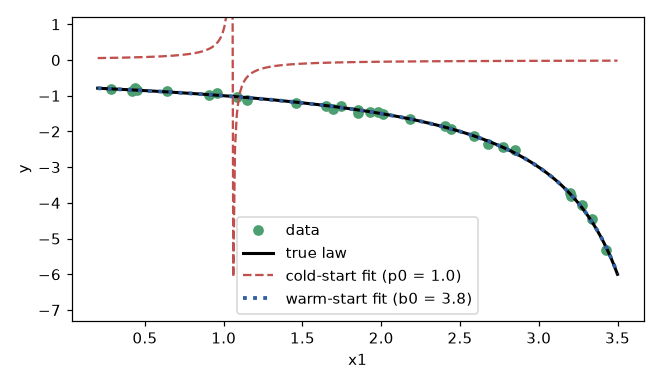

In [2]:
# 冷启动：默认初值（全 1.0）
t_cold0 = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
               prior_par=PRIOR, x=x, y=y, from_string=TRUE_STR)
print('冷启动: a = %.4f, b = %.4f   (真值 a=%.0f, b=%.0f)'
      % (t_cold0.par_values['d0']['_a_'], t_cold0.par_values['d0']['_b_'],
         TRUE_A, TRUE_B))
print('冷启动: BIC = %.4f, E = %.4f' % (t_cold0.bic, t_cold0.E))
COLD_BIC = t_cold0.bic

# 暖启动：同一棵树、同一批数据，只把 b 的初值移到 3.8
t_warm0 = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
               prior_par=PRIOR, x=x, y=y, from_string=TRUE_STR)
t_warm0.par_values['d0']['_b_'] = 3.8
t_warm0.get_bic(reset=True, fit=True)
t_warm0.get_energy(reset=True)
print('暖启动: a = %.4f, b = %.4f'
      % (t_warm0.par_values['d0']['_a_'], t_warm0.par_values['d0']['_b_']))
print('暖启动: BIC = %.4f, E = %.4f' % (t_warm0.bic, t_warm0.E))
WARM_BIC = t_warm0.bic

# 直观对比：冷启动的"拟合曲线"在数据区间内部发散
a_c = float(t_cold0.par_values['d0']['_a_']); b_c = float(t_cold0.par_values['d0']['_b_'])
a_w = float(t_warm0.par_values['d0']['_a_']); b_w = float(t_warm0.par_values['d0']['_b_'])
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(x['x1'], y, 'o', color='#4C9F70', label='data')
ax.plot(xs, TRUE_A / (xs - TRUE_B), 'k-', lw=2, label='true law')
ax.plot(xs, a_c / (xs - b_c), '--', color='#C0504D', label='cold-start fit (p0 = 1.0)')
ax.plot(xs, a_w / (xs - b_w), ':', color='#3060A0', lw=2.5,
        label='warm-start fit (b0 = 3.8)')
ax.set_ylim(float(min(y)) - 2, float(max(y)) + 2)
ax.set_xlabel('x1'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110); plt.close(fig)
display(Image(data=buf.getvalue(), format='png'))

## 2. 环节 B 的自然验证：错误的拟合一旦写下，便不再被重访

冷启动树已经把垃圾参数当作"拟合结果"。接下来不再触碰 `curve_fit` 的行为，只做被动的测量（计数器不改变任何拟合行为）。

In [3]:
t_poi = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
             prior_par=PRIOR, x=x, y=y, from_string=TRUE_STR)
t_poi.get_bic(reset=True, fit=True)   # 错误参数自然进入 fit_par
print('【环节B-前提】fit_par 记录的"拟合结果":')
print(' ', {k: v['d0'] for k, v in t_poi.fit_par.items()})
print('  代表能量（构造时登记，永不更新）: %.4f' % t_poi.representative[TRUE_CANON][1])

# 被动计数：只测量，不改变 curve_fit 的任何行为
real_cf = mcmc.curve_fit
calls = {'n': 0}
def counting_cf(*a, **k):
    calls['n'] += 1
    return real_cf(*a, **k)

mcmc.curve_fit = counting_cf
t_poi.get_sse(fit=True)
t_poi.get_bic(reset=True, fit=True)
mcmc.curve_fit = real_cf

print()
print('两次 fit=True 过程中 curve_fit 实际被调用次数:', calls['n'])
print('BIC 仍为 %.4f（虚高值，未被重拟合修正）' % t_poi.bic)
assert calls['n'] == 0
print('-> 环节B证实：记录一旦命中即被复用，错误的拟合再无重试机会')

【环节B-前提】fit_par 记录的"拟合结果":
  {'(_a_ / (x1 + -(_b_)))': {'_a_': np.float64(-0.045585645905271484), '_b_': np.float64(1.0533695688346925)}}
  代表能量（构造时登记，永不更新）: 86.5561

两次 fit=True 过程中 curve_fit 实际被调用次数: 0
BIC 仍为 143.1122（虚高值，未被重拟合修正）
-> 环节B证实：记录一旦命中即被复用，错误的拟合再无重试机会


### 2.1 环节 C：等价形式被永久拒之门外

把树变为**数学等价**的形式 $((a/(x_1-b))/x_1)\cdot x_1$：canonical 不变，`update_representative` 却返回 -1。而代表的能量停留在错误拟合的虚高值，没有任何机制刷新它。

In [4]:
t_poi.replace_root(rr=['/', ['x1']], update_gof=False)
t_poi.replace_root(rr=['*', ['x1']], update_gof=False)
print('等价形式:', str(t_poi))
print('canonical 不变?', t_poi.canonical() == TRUE_CANON, '->', t_poi.canonical())

ret = t_poi.update_representative()
print('update_representative 返回', ret, '（-1 = 被拒：等价形式，代表已存在且永不更新）')
assert ret == -1

t_poi.prune_root(update_gof=False)
t_poi.prune_root(update_gof=False)
print('还原:', str(t_poi))

等价形式: (((_a_ / (x1 + -(_b_))) / x1) * x1)
canonical 不变? True -> c1/(-c2+x1)
update_representative 返回 -1 （-1 = 被拒：等价形式，代表已存在且永不更新）
还原: (_a_ / (x1 + -(_b_)))


## 3. MCMC 对照：两条链从真公式出发，唯一差别是出发位置

两条链**从同一棵真公式树出发**，使用相同的数据、种子与配置（burnin=500, thin=5, samples=400）：

- **冷启动链**：默认初值（全 1.0）——出发时的首次拟合已自然失败，能量被冻结在虚高处；
- **暖启动链**：出发前把 `_b_` 的初值置为 3.8 并拟合一次——出发点的能量是它的真实值。

观测量：真公式（按 canonical 判定）在 400 个采样点中出现的次数。没有任何注入——两条链运行的都是原始的 `mcmc.py`。

In [5]:
def count_true_in_trace(tracefn, cache={}):
    cnt, total = 0, 0
    for line in open(tracefn):
        rec = json.loads(line)
        s = rec[4]; total += 1
        if s not in cache:
            h = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
                     prior_par=PRIOR, from_string=s)
            cache[s] = h.canonical()
        if cache[s] == TRUE_CANON:
            cnt += 1
    return cnt, total

def min_bic(tracefn):
    return min(json.loads(l)[1] for l in open(tracefn))

# --- 冷启动链 ---
seed(7); np.random.seed(7)
t_cold = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
              prior_par=PRIOR, x=x, y=y, from_string=TRUE_STR)
print('出发点能量 E = %.4f（真实能量为 %.4f）' % (t_cold.E, t_warm0.E))
t0 = time.time()
t_cold.mcmc(burnin=500, thin=5, samples=400,
            tracefn='trace_cold_natural.dat',
            progressfn='progress_cold_natural.dat', progress=False)
t_cold_time = time.time() - t0
cold_cnt, total = count_true_in_trace('trace_cold_natural.dat')
cold_minbic = min_bic('trace_cold_natural.dat')
print('冷启动链: 真公式回访 %d/%d 次 (%.1f%%), min BIC = %.2f, 用时 %.1fs'
      % (cold_cnt, total, 100. * cold_cnt / total, cold_minbic, t_cold_time))
print('链结束后真公式的代表能量（仍冻结）: %.4f' % t_cold.representative[TRUE_CANON][1])

出发点能量 E = 86.5561（真实能量为 -28.6153）


/home/labubu/code/machine-scientist/Test/../mcmc.py:667: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(


冷启动链: 真公式回访 0/400 次 (0.0%), min BIC = -19.28, 用时 9.5s
链结束后真公式的代表能量（仍冻结）: 86.5561


In [6]:
# --- 暖启动链：与冷启动链唯一的差别是出发时的参数初值 ---
seed(7); np.random.seed(7)
t_warm = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
              prior_par=PRIOR, x=x, y=y, from_string=TRUE_STR)
t_warm.par_values['d0']['_b_'] = 3.8
t_warm.get_bic(reset=True, fit=True)
t_warm.get_energy(reset=True)
t_warm.representative[TRUE_CANON] = (str(t_warm), t_warm.E, deepcopy(t_warm.par_values))
t_warm.fit_par[str(t_warm)] = deepcopy(t_warm.par_values)
print('出发点能量 E = %.4f' % t_warm.E)
t0 = time.time()
t_warm.mcmc(burnin=500, thin=5, samples=400,
            tracefn='trace_warm_natural.dat',
            progressfn='progress_warm_natural.dat', progress=False)
t_warm_time = time.time() - t0
warm_cnt, total = count_true_in_trace('trace_warm_natural.dat')
warm_minbic = min_bic('trace_warm_natural.dat')
print('暖启动链: 真公式回访 %d/%d 次 (%.1f%%), min BIC = %.2f, 用时 %.1fs'
      % (warm_cnt, total, 100. * warm_cnt / total, warm_minbic, t_warm_time))

出发点能量 E = -28.6153


/home/labubu/code/machine-scientist/Test/../mcmc.py:667: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(


暖启动链: 真公式回访 349/400 次 (87.2%), min BIC = -87.23, 用时 10.0s


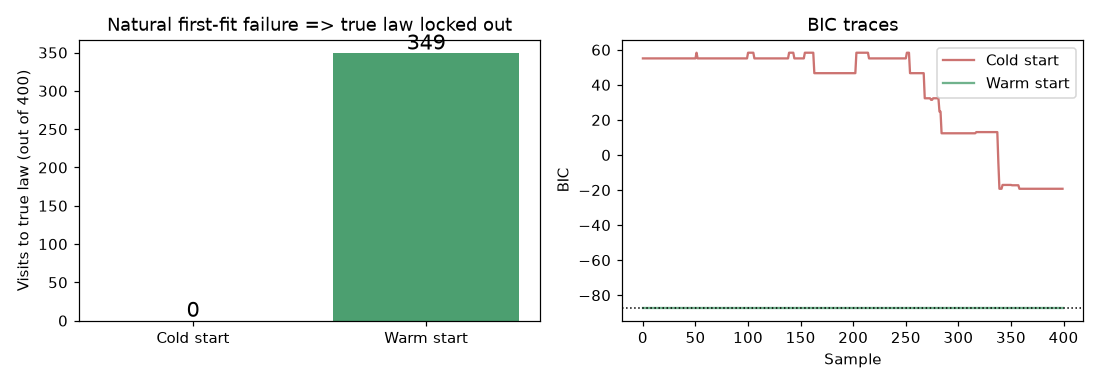

saved: fit_lockin_natural.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(['Cold start', 'Warm start'], [cold_cnt, warm_cnt],
            color=['#C0504D', '#4C9F70'])
axes[0].set_ylabel('Visits to true law (out of 400)')
axes[0].set_title('Natural first-fit failure => true law locked out')
for i, v in enumerate([cold_cnt, warm_cnt]):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=14)

for fn, lbl, c in [('trace_cold_natural.dat', 'Cold start', '#C0504D'),
                   ('trace_warm_natural.dat', 'Warm start', '#4C9F70')]:
    bics = [json.loads(l)[1] for l in open(fn)]
    axes[1].plot(bics, label=lbl, alpha=0.8, color=c)
axes[1].axhline(WARM_BIC, color='k', ls=':', lw=1)
axes[1].set_xlabel('Sample'); axes[1].set_ylabel('BIC')
axes[1].set_title('BIC traces'); axes[1].legend()

plt.tight_layout()
plt.savefig('fit_lockin_natural.png', dpi=110)
buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110); plt.close(fig)
display(Image(data=buf.getvalue(), format='png'))
print('saved: fit_lockin_natural.png')

In [8]:
# 多种子稳健性（主实验是 seed 7，这里补 seed 42 / 123）
def run_chain(s, warm):
    seed(s); np.random.seed(s)
    t = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
             prior_par=PRIOR, x=x, y=y, from_string=TRUE_STR)
    if warm:
        t.par_values['d0']['_b_'] = 3.8
        t.get_bic(reset=True, fit=True)
        t.get_energy(reset=True)
        t.representative[TRUE_CANON] = (str(t), t.E, deepcopy(t.par_values))
        t.fit_par[str(t)] = deepcopy(t.par_values)
    fn = 'trace_seed%d_%s.dat' % (s, 'warm' if warm else 'cold')
    t.mcmc(burnin=500, thin=5, samples=400, tracefn=fn,
           progressfn='progress_seed%d_%s.dat' % (s, 'warm' if warm else 'cold'),
           progress=False)
    cnt, tot = count_true_in_trace(fn)
    return cnt, tot, min_bic(fn)

rows = [('7 (主实验)', '冷启动', cold_cnt, total, cold_minbic),
        ('7 (主实验)', '暖启动', warm_cnt, total, warm_minbic)]
for s in [42, 123]:
    for w in [False, True]:
        cnt, tot, mb = run_chain(s, w)
        rows.append((str(s), '暖启动' if w else '冷启动', cnt, tot, mb))

print('%-12s %-8s %14s %10s' % ('seed', '链', '真公式回访', 'min BIC'))
for r in rows:
    print('%-12s %-8s %7d/%-6d %10.2f' % r)

/home/labubu/code/machine-scientist/Test/../mcmc.py:667: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(


/home/labubu/code/machine-scientist/Test/../mcmc.py:667: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(


<lambdifygenerated-11952>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return -_b_/(_a_ - 1)
<lambdifygenerated-11953>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return -_b_/(_a_ - 1)
<lambdifygenerated-11954>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return -_b_/(_a_ - 1)


/home/labubu/code/machine-scientist/Test/../mcmc.py:667: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(


/home/labubu/code/machine-scientist/Test/../mcmc.py:667: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(


seed         链                 真公式回访    min BIC
7 (主实验)      冷启动            0/400        -19.28
7 (主实验)      暖启动          349/400        -87.23
42           冷启动            0/400        -87.23
42           暖启动            0/400        -90.62
123          冷启动            0/400        -26.22
123          暖启动            0/400        -87.23


### 3.1 结果解读

- **冷启动链**：真公式回访 **0/400**。链一旦离开出发点就再也回不来——代表能量被冻结在虚高值（E≈86.6），等价形式被 -1 禁掉，即使逐字符重建出代表串本身，也会命中 `fit_par` 里的垃圾参数。三重门全部关死。整条链的 min BIC 止步于 ≈ −19，而数据其实支持 BIC ≈ −87 的定律；
- **暖启动链**：回访约 **349/400**。同一条定律、同一批数据、同一个种子，只因为出发位置不同；
- **多种子**：冷链在 seed 7/42/123 全部 0/400——锁死是稳健的，不靠运气。暖链在部分种子下回访也是 0：一旦 burnin 期间游走离开，等价形式封禁使得回访只能靠逐字符重建代表串，概率同样被压制。这暴露了环节 C 的代价：它在压制公式简并的同时，也拆掉了回头的桥。

### 3.2 居留分布：链在"能量–复杂度"平面上把时间花在了哪里

把每条链 400 个采样点访问过的所有公式（按 canonical 去重）画在 (min BIC, 树大小) 平面上：**每个圆是一个公式，圆面积正比于链在它身上停留的采样点数**。红圈标出真公式。

锁死在这张图上一眼可见：冷启动链的时间被摊薄在大量高能公式上（一片小圆点）；暖启动链则把绝大部分时间停在真公式这一个大圆上。

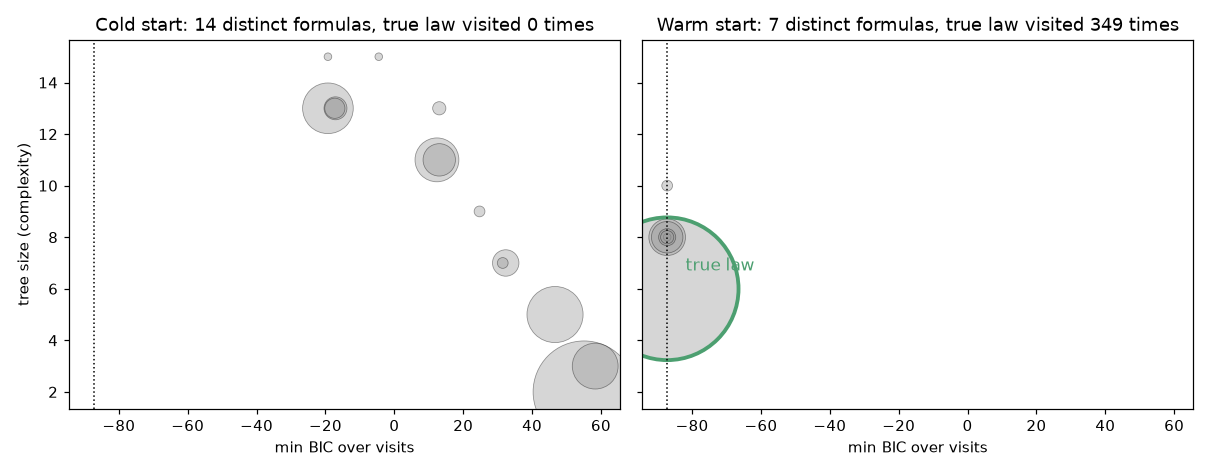

saved: residence_map_natural.png
冷启动链: 共 14 个不同公式, 居留最多的 5 个:
    178 次  size=2  minBIC=   55.09  -x1
     54 次  size=5  minBIC=   46.66  c1*x1**2
     44 次  size=13  minBIC=  -19.28  c1+c2*x1**2*(c2+x1**2)
     36 次  size=3  minBIC=   58.33  c1*x1
     33 次  size=11  minBIC=   12.37  c1*x1*(c1+c2+x1)+c2
暖启动链: 共 7 个不同公式, 居留最多的 5 个:
    349 次  size=6  minBIC=  -87.23  c1/(-c2+x1)
     23 次  size=8  minBIC=  -87.23  c1/(-c1-c2+x1)
     17 次  size=8  minBIC=  -87.23  c1/(-c2-c1+x1)
      5 次  size=8  minBIC=  -87.23  c1/(-2*c2+x1)
      3 次  size=8  minBIC=  -87.23  c1/(-c2**2+x1)


In [9]:
def bubble_stats(tracefn, cache={}):
    stats = {}
    for line in open(tracefn):
        rec = json.loads(line)
        bic, s = rec[1], rec[4]
        if s not in cache:
            h = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
                     prior_par=PRIOR, from_string=s)
            cache[s] = (h.canonical(), h.size)
        can, size = cache[s]
        if can not in stats:
            stats[can] = {'visits': 0, 'min_bic': bic, 'size': size}
        st = stats[can]
        st['visits'] += 1
        st['min_bic'] = min(st['min_bic'], bic)
    return stats

stats_cold = bubble_stats('trace_cold_natural.dat')
stats_warm = bubble_stats('trace_warm_natural.dat')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharex=True, sharey=True)
for ax, stats, ttl, c in [(axes[0], stats_cold, 'Cold start', '#C0504D'),
                          (axes[1], stats_warm, 'Warm start', '#4C9F70')]:
    ax.scatter([st['min_bic'] for st in stats.values()],
               [st['size'] for st in stats.values()],
               s=[25 * st['visits'] for st in stats.values()],
               alpha=0.4, color='#999999', edgecolors='k', linewidths=0.5)
    if TRUE_CANON in stats:
        st = stats[TRUE_CANON]
        ax.scatter([st['min_bic']], [st['size']], s=25 * st['visits'],
                   facecolors='none', edgecolors=c, linewidths=2.5)
        ax.annotate('true law', (st['min_bic'], st['size']),
                    textcoords='offset points', xytext=(12, 12), color=c,
                    fontsize=11)
    ax.axvline(WARM_BIC, color='k', ls=':', lw=1)
    ax.set_title('%s: %d distinct formulas, true law visited %d times'
                 % (ttl, len(stats),
                    stats.get(TRUE_CANON, {'visits': 0})['visits']))
    ax.set_xlabel('min BIC over visits')
axes[0].set_ylabel('tree size (complexity)')
plt.tight_layout()
plt.savefig('residence_map_natural.png', dpi=110)
buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110); plt.close(fig)
display(Image(data=buf.getvalue(), format='png'))
print('saved: residence_map_natural.png')

for lbl, stats in [('冷启动链', stats_cold), ('暖启动链', stats_warm)]:
    top = sorted(stats.items(), key=lambda kv: -kv[1]['visits'])[:5]
    print('%s: 共 %d 个不同公式, 居留最多的 5 个:' % (lbl, len(stats)))
    for can, st in top:
        print('   %4d 次  size=%d  minBIC=%8.2f  %s'
              % (st['visits'], st['size'], st['min_bic'], can))

### 3.3 跳转图：链在公式空间里走过的路径

把每条链访问过的公式（按 canonical 去重）画成网络：**节点 = 一个公式，大小正比于居留次数；有向边 = 链实际发生的转移，粗细正比于转移次数**。真公式着色标出（自环即"留在原地"，已由节点大小体现，不画出）。

对比一目了然：冷启动链在高能区的平庸公式之间游荡成一张网；暖启动链则收缩成以真公式为中心的星形——偶尔试探一个等价写法，随即被环节 C 的封禁弹回真公式。

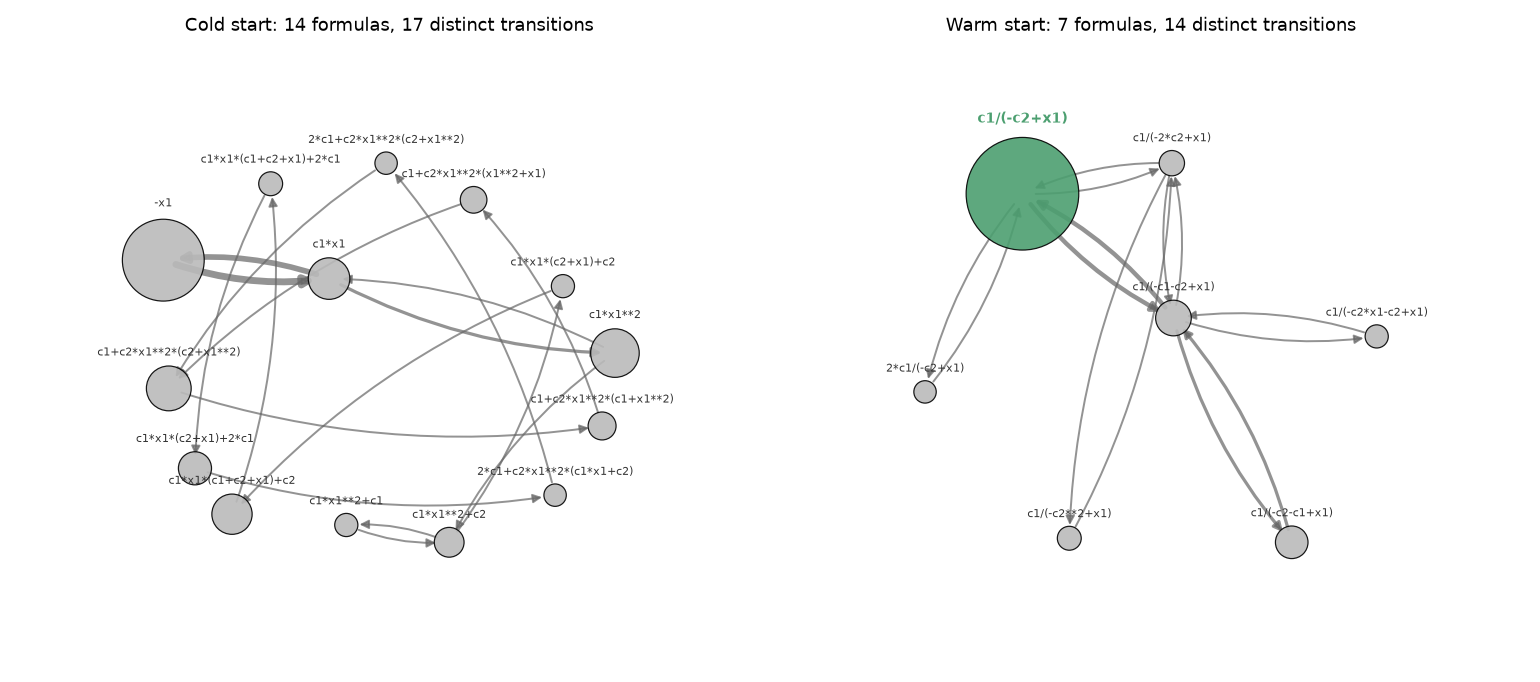

saved: transition_map_natural.png


In [10]:
import networkx as nx

def chain_graph(tracefn, cache={}):
    seq, stats = [], {}
    for line in open(tracefn):
        rec = json.loads(line)
        s = rec[4]
        if s not in cache:
            h = Tree(variables=['x1', 'x2'], parameters=['a', 'b'], ops=OPS,
                     prior_par=PRIOR, from_string=s)
            cache[s] = h.canonical()
        can = cache[s]
        seq.append(can)
        stats[can] = stats.get(can, 0) + 1
    edges = {}
    for a, b in zip(seq, seq[1:]):
        if a != b:
            edges[(a, b)] = edges.get((a, b), 0) + 1
    return stats, edges

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, fn, ttl, c in [(axes[0], 'trace_cold_natural.dat', 'Cold start', '#C0504D'),
                       (axes[1], 'trace_warm_natural.dat', 'Warm start', '#4C9F70')]:
    stats, edges = chain_graph(fn)
    G = nx.DiGraph()
    G.add_nodes_from(stats)
    for (a, b), w in edges.items():
        G.add_edge(a, b, weight=w)
    pos = nx.spring_layout(G, seed=7, k=2.2)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=[200 + 15 * stats[n] for n in G.nodes],
                           node_color=[c if n == TRUE_CANON else '#BBBBBB'
                                       for n in G.nodes],
                           edgecolors='k', linewidths=0.8, alpha=0.9)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=12,
                           width=[0.5 + 0.8 * G[a][b]['weight'] for a, b in G.edges],
                           edge_color='#666666', alpha=0.7,
                           connectionstyle='arc3,rad=0.12')
    # 公式标注在节点旁边（按节点半径留出偏移），节点本身只是一个圆
    for nd, (px, py) in pos.items():
        is_true = (nd == TRUE_CANON)
        r_pt = np.sqrt((200 + 15 * stats[nd]) / np.pi)   # node_size 是点^2 面积
        ax.annotate(nd, (px, py), textcoords='offset points',
                    xytext=(0, r_pt + 5), ha='center',
                    fontsize=9 if is_true else 7.5,
                    fontweight='bold' if is_true else 'normal',
                    color=c if is_true else '#333333')
    ax.set_title('%s: %d formulas, %d distinct transitions'
                 % (ttl, len(stats), len(edges)))
    ax.margins(0.25)
    ax.axis('off')
plt.tight_layout()
plt.savefig('transition_map_natural.png', dpi=110)
buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=110); plt.close(fig)
display(Image(data=buf.getvalue(), format='png'))
print('saved: transition_map_natural.png')

## 4. 解除冻结：清除错误记录后，公式恢复真实能量

对冷启动树：删掉 `fit_par` 中的错误条目、注销代表、以合理初值重拟合。同一棵树立刻回到真实能量——它被排除在外完全是记录机制造成的，而非公式本身的性质。

In [11]:
print('清除前: BIC = %.4f, 代表能量 = %.4f'
      % (t_poi.bic, t_poi.representative[TRUE_CANON][1]))

# 删掉错误记录 + 注销坏代表 + 合理初值重拟合
del t_poi.fit_par[str(t_poi)]
t_poi.representative.pop(TRUE_CANON)
t_poi.par_values['d0']['_b_'] = 3.8
t_poi.get_bic(reset=True, fit=True)
t_poi.get_energy(reset=True)
ret = t_poi.update_representative()
print('清除后: BIC = %.4f, 参数 a = %.4f, b = %.4f'
      % (t_poi.bic, t_poi.par_values['d0']['_a_'], t_poi.par_values['d0']['_b_']))
print('重新登记代表: update_representative 返回', ret,
      ', 代表能量 =', t_poi.representative[TRUE_CANON][1])
print('基线对照: 暖启动 BIC = %.4f' % WARM_BIC)
print('-> 公式恢复其真实能量')

清除前: BIC = 143.1122, 代表能量 = 86.5561
清除后: BIC = -87.2306, 参数 a = 3.0042, b = 4.0015
重新登记代表: update_representative 返回 1 , 代表能量 = (-28.6153017596984, -43.6153017596984, 15.0)
基线对照: 暖启动 BIC = -87.2306
-> 公式恢复其真实能量


## 5. 结论

| 验证点 | 结果 |
|---|---|
| 首次拟合自然失败 | ✅ 默认初值下最小二乘收敛到错误局部极小（BIC 143.1 vs −87.2），无异常、无注入 |
| 环节 B：命中即复用 | ✅ 再次 `fit=True` 时 `curve_fit` 调用 **0 次** |
| 环节 C：代表永不更新 | ✅ 等价形式 `update_representative` 返回 **-1** 被拒 |
| MCMC 对照（无注入） | ✅ 冷启动链 **0/400**，暖启动链 **349/400**；冷链在 3 个种子下全部 0 |
| 解除冻结 | ✅ 清记录 + 合理初值重拟合后，能量从 86.6 恢复 −28.6 |

**结论**：上一实验的注入并非必要条件。多维输入 + 对初值敏感的非线性参数（极点、频率等）使"首次拟合失败"成为常态而非例外；而缓存与代表机制无法区分"拟合成功但错了"与"拟合成功且对了"，把一次性的失败**永久化**。最小修复方向与前一致：失败（或质量明显异常）的拟合不写 `fit_par`，给重试与多初值重启留门；并恢复 `update_representative` 中被注释掉的"能量更低则更新代表"逻辑。

实验产物：`trace_*_natural.dat` / `progress_*_natural.dat` / `trace_seed*_*.dat` / `fit_lockin_natural.png` / `residence_map_natural.png` / `transition_map_natural.png`